In [1]:
import polars as pl 

BKS = {
    "tsp": pl.read_csv("../../bks/tsp_bks.csv"),
    "csp": pl.read_csv("../../bks/csp_bks.csv"),
    "pdptw": pl.read_csv("../../bks/pdptw_bks.csv")
}

In [2]:
import orjson
from typing import Literal
from dataclasses import dataclass
from abc import abstractmethod, ABC
from functools import cached_property


def primal_gap(obj: float, bks: float, is_feasible: bool) -> float:
    if not is_feasible:
        return 1.0
    if obj == bks:
        return 0.0
    return (bks - obj) / max(bks, obj)


@dataclass
class ObjOverTime:
    timestamps: list[float]
    objectives: list[float]

    def at(self, t: float):
        # Dichotomic search across timestamps
        left, right = 0, len(self.timestamps) - 1
        if t < self.timestamps[0]:
            return None
        if t > self.timestamps[-1]:
            return self.objectives[-1]
        while left < right:
            idx = (left + right) // 2
            if self.timestamps[idx] == t:
                return self.objectives[idx]
            if self.timestamps[idx] < t:
                left = idx + 1
            else:
                right = idx - 1
        return self.objectives[idx]

    @staticmethod
    def parse(sol_over_time: str):
        saved = sol_over_time
        try:
            sol_over_time = sol_over_time.replace("-", ",")
            data = orjson.loads(sol_over_time)
        except orjson.JSONDecodeError:
            # Old format [(t:0.423-v:361.000)-(t:0.424-v:360.000)]
            sol_over_time = saved.replace("(t:", '{"t":')
            sol_over_time = sol_over_time.replace("-v:", ',"v":')
            sol_over_time = sol_over_time.replace(")-", "},")
            sol_over_time = sol_over_time.replace(")]", "}]")
            data = orjson.loads(sol_over_time)
        # flatten to two lists instead of a list of objects
        timestamps = [point["t"] for point in data]
        objectives = [point["v"] for point in data]
        return ObjOverTime(timestamps=timestamps, objectives=objectives)


@dataclass
class Result(ABC):
    problem: Literal["csp", "tsp", "pdptw"]
    instance: str
    oot: ObjOverTime

    @classmethod
    def parse(cls, row: dict):
        full_instance = row["instance"]
        _, problem, *_, instance = full_instance.split("/")
        return cls(problem, instance, ObjOverTime.parse(row["sol_over_time"]))

    @cached_property
    def bks(self) -> float:
        row = BKS[self.problem].filter(pl.col("instance") == self.instance).select("bks")
        if row.is_empty():
            return 0.0
        return row.item()

    @abstractmethod
    def is_feasible(self, t: float) -> bool:
        """Whether the solution is feasible or not at timestamp t."""

    def primal_gap(self, t: float):
        if not self.is_feasible(t):
            return 1.0
        obj = self.oot.at(t)
        assert obj is not None
        return primal_gap(obj, self.bks, self.is_feasible(t))


class CSPResult(Result):
    def is_feasible(self, t: float) -> bool:
        return self.oot.at(t) == 0


class PDPTWResult(Result):
    UNROUTED_NODE_PENALTY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        assert obj is not None
        return obj < PDPTWResult.UNROUTED_NODE_PENALTY


class TSPResult(Result):
    UNROUTED_NODE_PENALY = 1000000000

    def is_feasible(self, t: float) -> bool:
        obj = self.oot.at(t)
        assert obj is not None
        return obj < TSPResult.UNROUTED_NODE_PENALY

# Primal gap over time

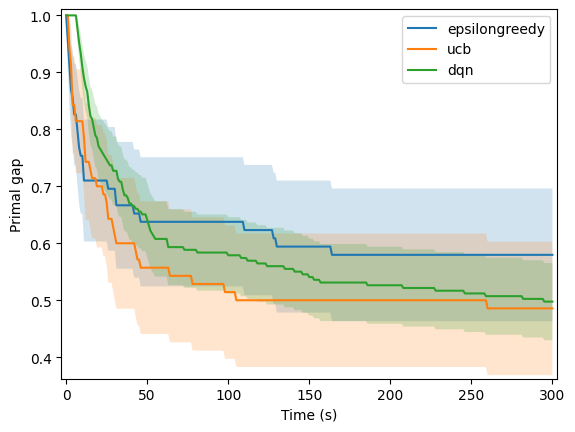

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def primal_gaps_over_time(results: list[Result], tmax: float):
    gaps = []
    for r in results:
        gaps.append([r.primal_gap(t) for t in range(int(tmax) + 1)])
    return np.array(gaps)


def plot_pg_by_bandit(df: pl.DataFrame, tmax: float, reward: Literal["r1", "r2", "r3"]):
    df = df.filter(pl.col("reward") == reward)
    problem = df["instance"][0].split("/")[1]
    xs = np.arange(int(tmax) + 1)
    for name, bandit in df.group_by(pl.col("bandit")):
        match problem:
            case "csp":
                results = [CSPResult.parse(row) for row in bandit.iter_rows(named=True)]
            case other:
                raise NotImplementedError(f"Not implemented for problem type: {other}")
        arr = primal_gaps_over_time(results, tmax) # type: ignore
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / np.sqrt(arr.shape[0])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
        plt.xlabel("Time (s)")
        plt.ylabel("Primal gap")
        plt.margins(x=0.01, y=0.01)
    plt.legend()


plot_pg_by_bandit(pl.read_csv("csp_all.csv"), tmax=300, reward="r2")